# HW3 — Large-Liquidation Reaction Filter

**Goal.** Build a binary filter $f_i\in\{0,1\}$ over Binance maker trades that *removes* the
trades made toxic by large liquidations, so that the maker PnL on the **kept** trades beats
the PnL on **all** trades, while keeping $\ge\$500\text{k}/\text{day}$ of clipped turnover.

This builds directly on the Task-2 baseline (`baseline.py`): same data loaders, same
markout-PnL definition, same metric formulas. Here we isolate a **single, interpretable
signal** — the reaction to *large liquidations* — instead of the Task-2 ensemble, and compare.

### Conventions (from `liquidation_task/description.md`)
* `timestamp` = microseconds since UNIX epoch (UTC); single time axis.
* **trade `side`** = taker side: `buy` ⇒ taker bought ⇒ *maker sold* ($s_i=+1$); `sell` ⇒ $s_i=-1$.
* **liquidation `side`** = the liquidation order side: `buy` ⇒ forced buying ⇒ **upward** pressure.
* Maker PnL (bps) at horizon $\tau$ (with $+0.5$ bps rebate, forward-filled mid at $t_i+\tau$):
  $$\text{pnl}_i(\tau) = -s_i\,\frac{m_i(\tau)-p_i}{p_i}\cdot 10^4 + 0.5,\qquad w_i=\min(\text{notional}_i,\$100\text{k}).$$
* $\text{Score}(\tau)=\text{PnL}_{\text{kept}}(\tau)-\text{PnL}_{\text{all}}(\tau)$ — higher is better.
* Cross-exchange latency: Bybit liquidation timestamps are shifted **+200 ms** before use.
* Splits: **train** Dec'25–Jan'26, **validation** Feb'26.

### Plan
1. **Data / thresholds** — distribution of liquidation notional; define "large" via the 90/95/99th percentiles.
2. **EDA** — for each large liquidation, the average $\tau{=}30\text{s}$ markout of in-window trades
   (0–300 s after), split into *same-direction* vs *opposite-direction*. Where does the reaction peak / fade?
3. **Filter** — pick `liq_threshold` (USD) and `window_seconds`; implement `classify_trades`.
4. **Measure** — Score($\tau$), PnL_kept, PnL_filtered, KeptTurnoverPerDay on train & val vs the Task-2 baseline.

In [1]:
import json
from pathlib import Path

import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

import baseline as B          # Task-2: loaders, markout_pnl_bps, metric formulas
import hw3_liq_filter as H     # HW3: reaction curves + the large-liquidation filter

# False -> load the cached numbers (fast, reproducible plots/tables).
# True  -> recompute everything from the raw parquet day-by-day (slow: loads ~6 GB of trades).
RECOMPUTE = False

SYM = "BTC"                    # EDA / measurement symbol (matches the Task-2 baseline)
TAUS_S = B.TAUS_S              # (30, 120, 300)
PCTLS = (90, 95, 99)
plt.rcParams["figure.dpi"] = 110
CURVES_NPZ = Path("hw3_curves.npz")
METRICS_JSON = Path("hw3_metrics.json")
print("taus:", TAUS_S, "| RECOMPUTE:", RECOMPUTE)

taus: (30, 120, 300) | RECOMPUTE: False


## 1. Liquidation notional & the "large liquidation" thresholds

Liquidation notional $=\text{price}\times\text{amount}$ (USD). The distribution is extremely
heavy-tailed, so we define "large" by upper percentiles rather than a hand-picked number. We
compute the thresholds on the **train** window only (no look-ahead) and reuse those USD values on
validation. (BTC and ETH have similar USD scales, so a per-symbol threshold is robust.)

In [2]:
# Liquidation tables are small (~few MB) -> load fully and compute percentiles directly.
TRAIN_LO, TRAIN_HI = B._epoch_us(2025, 12, 1), B._epoch_us(2026, 2, 1)

def load_liq_notional(folder, fname, lo, hi):
    liq = (pl.scan_parquet(B.DATA / folder / f"{fname}.parquet")
           .filter((pl.col("timestamp") >= lo) & (pl.col("timestamp") < hi))
           .select(["side", "price", "amount"]).collect(engine="streaming"))
    return liq, (liq["price"] * liq["amount"]).to_numpy()

liq_btc, notional = load_liq_notional("binance_liquidations", B.SYM_FILE["BTC"], TRAIN_LO, TRAIN_HI)
thr_btc = {q: float(np.percentile(notional, q)) for q in PCTLS}

rows = [("count", f"{len(notional):,}"), ("buy-side %", f"{100*(liq_btc['side']=='buy').mean():.1f}%"),
        ("mean $", f"{notional.mean():,.0f}"), ("median $", f"{np.median(notional):,.0f}"),
        ("max $", f"{notional.max():,.0f}")]
for q in (50, 75, *PCTLS, 99.9):
    rows.append((f"{q}th pctl $", f"{np.percentile(notional, q):,.0f}"))
print("BTC Binance liquidations, train window:")
for k, v in rows:
    print(f"  {k:>14}: {v:>14}")
print("\nChosen 'large' thresholds (USD):", {q: round(v) for q, v in thr_btc.items()})

BTC Binance liquidations, train window:
           count:         63,660
      buy-side %:          43.2%
          mean $:         11,587
        median $:          1,154
           max $:     12,196,879
     50th pctl $:          1,154
     75th pctl $:          4,441
     90th pctl $:         16,821
     95th pctl $:         39,358
     99th pctl $:        171,682
   99.9th pctl $:        804,283

Chosen 'large' thresholds (USD): {90: 16821, 95: 39358, 99: 171682}


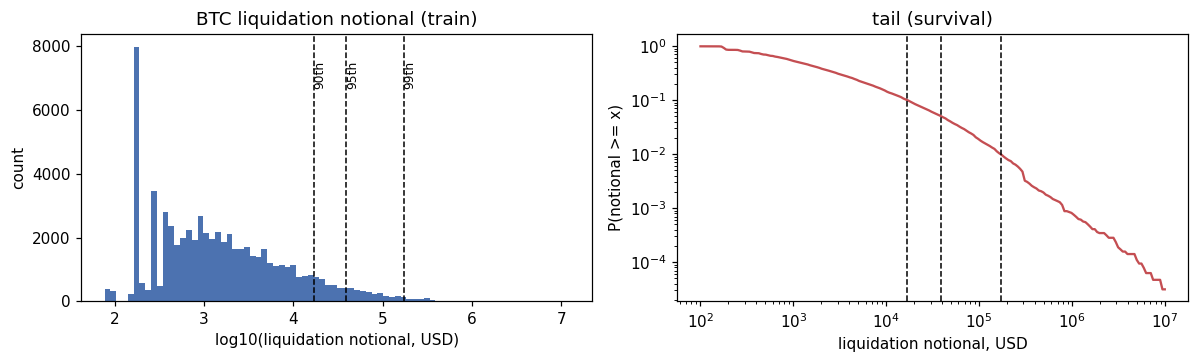

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(np.log10(notional[notional > 0]), bins=80, color="#4C72B0")
for q in PCTLS:
    ax[0].axvline(np.log10(thr_btc[q]), ls="--", lw=1, color="k")
    ax[0].text(np.log10(thr_btc[q]), ax[0].get_ylim()[1]*0.9, f"{q}th", rotation=90, va="top", fontsize=8)
ax[0].set_xlabel("log10(liquidation notional, USD)"); ax[0].set_ylabel("count")
ax[0].set_title("BTC liquidation notional (train)")

# survival / tail: fraction of liqs above a notional
xs = np.logspace(2, 7, 200)
surv = [(notional >= x).mean() for x in xs]
ax[1].loglog(xs, surv, color="#C44E52")
for q in PCTLS:
    ax[1].axvline(thr_btc[q], ls="--", lw=1, color="k")
ax[1].set_xlabel("liquidation notional, USD"); ax[1].set_ylabel("P(notional >= x)")
ax[1].set_title("tail (survival)")
plt.tight_layout(); plt.show()

## 2. EDA — the reaction to a large liquidation

**Event study.** For every large liquidation at time $t_{\text{liq}}$ we look at all Binance trades
in the window $[t_{\text{liq}},\,t_{\text{liq}}+300\text{s}]$. Each such trade gets its
$\tau{=}30\text{s}$ maker markout $\text{pnl}_i(30\text{s})$. We bucket trades by *time after the
liquidation* (10 s buckets) and average, separately for:

* **same direction** — the trade's taker side equals the liquidation side (e.g. taker *buy* after a *buy*-liquidation);
* **opposite direction** — the trade's taker side is opposite the liquidation side.

A negative same-direction markout means the maker who absorbed the with-the-liquidation flow is
adversely selected → those are the trades to filter. We pool across all large liquidations and try
the 90/95/99th-percentile thresholds.

In [4]:
# --- reaction curves: load cache, or recompute live over sampled train days ---
def compute_curves_live(stride_days=3, window_s=300, bucket_s=10):
    pad_us = max(TAUS_S) * 1_000_000 + 5_000_000
    accs = {q: {t: None for t in TAUS_S} for q in PCTLS}
    day, n_days = TRAIN_LO, 0
    while day < TRAIN_HI:
        trades, bbo, liq_bn, _ = B.load_day(SYM, day, day + B.DAY_US, pad_us)
        day += stride_days * B.DAY_US
        if trades.is_empty() or bbo.is_empty():
            continue
        n_days += 1
        for q in PCTLS:
            for t in TAUS_S:
                accs[q][t] = H.reaction_curves(
                    trades, bbo, liq_bn, thr_btc[q], window_s=window_s, bucket_s=bucket_s,
                    tau_us=t * 1_000_000, acc=accs[q][t])
    return accs, n_days

if RECOMPUTE or not CURVES_NPZ.exists():
    accs, n_days_eda = compute_curves_live()
    edges = accs[PCTLS[0]][TAUS_S[0]]["edges"]
    def curve_mean(q, t, key): return H.curve_means(accs[q][t], key)
    def curve_cnt(q, t, key):  return accs[q][t][key]["cnt"]
else:
    Z = np.load(CURVES_NPZ)
    edges = Z["edges"]; n_days_eda = int(Z["train_days"][0])
    def curve_mean(q, t, key):
        s, c = Z[f"q{q}_t{t}_{key}_sum"], Z[f"q{q}_t{t}_{key}_cnt"]
        return np.where(c > 0, s / np.maximum(c, 1.0), np.nan)
    def curve_cnt(q, t, key):  return Z[f"q{q}_t{t}_{key}_cnt"]

print(f"reaction curves pooled over {n_days_eda} train days")

reaction curves pooled over 21 train days


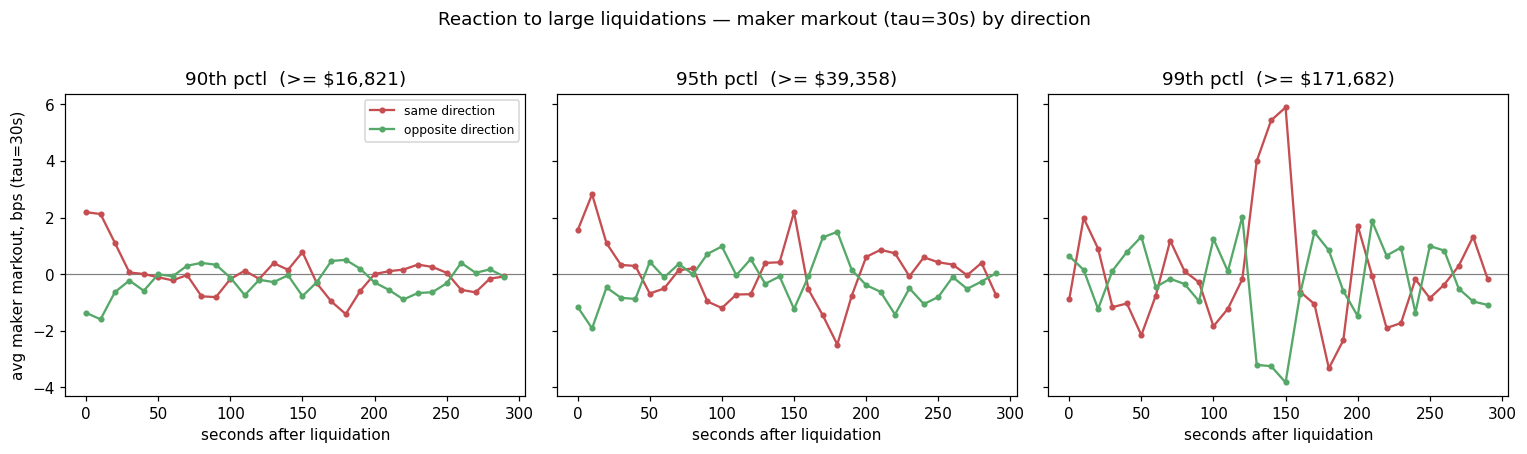

In [5]:
# --- required plot: tau=30s same vs opposite markout, one panel per threshold ---
fig, axes = plt.subplots(1, len(PCTLS), figsize=(14, 4), sharey=True)
for ax, q in zip(axes, PCTLS):
    same = curve_mean(q, 30, "same"); opp = curve_mean(q, 30, "opp")
    ax.axhline(0, color="grey", lw=0.8)
    ax.plot(edges, same, "-o", ms=3, color="#C44E52", label="same direction")
    ax.plot(edges, opp,  "-o", ms=3, color="#55A868", label="opposite direction")
    ax.set_title(f"{q}th pctl  (>= ${thr_btc[q]:,.0f})")
    ax.set_xlabel("seconds after liquidation")
axes[0].set_ylabel("avg maker markout, bps (tau=30s)")
axes[0].legend(loc="best", fontsize=8)
fig.suptitle("Reaction to large liquidations — maker markout (tau=30s) by direction", y=1.02)
plt.tight_layout(); plt.show()

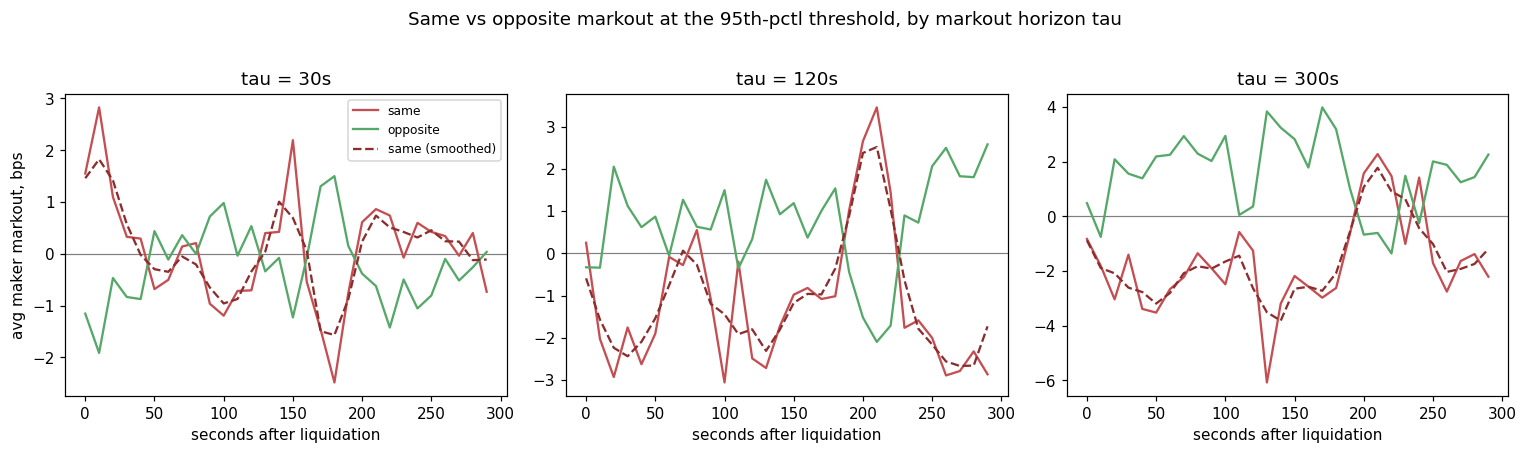

In [6]:
# --- companion: how the reaction deepens with the markout horizon tau (95th pctl) ---
# The tau=30s view is noisy; the with-the-liquidation toxicity is a slow CONTINUATION that
# shows up clearly at longer markout horizons. We plot the same vs opposite curves for each tau.
q = 95
fig, axes = plt.subplots(1, len(TAUS_S), figsize=(14, 4), sharey=False)
for ax, t in zip(axes, TAUS_S):
    same = curve_mean(q, t, "same"); opp = curve_mean(q, t, "opp")
    ax.axhline(0, color="grey", lw=0.8)
    ax.plot(edges, same, "-", color="#C44E52", label="same")
    ax.plot(edges, opp,  "-", color="#55A868", label="opposite")
    # smoothed same-direction (rolling mean) to see the trend through the noise
    k = 3
    sm = np.convolve(np.nan_to_num(same), np.ones(k)/k, mode="same")
    ax.plot(edges, sm, "--", color="#8C2D2D", lw=1.5, label="same (smoothed)")
    ax.set_title(f"tau = {t}s"); ax.set_xlabel("seconds after liquidation")
axes[0].set_ylabel("avg maker markout, bps")
axes[0].legend(fontsize=8)
fig.suptitle(f"Same vs opposite markout at the 95th-pctl threshold, by markout horizon tau", y=1.02)
plt.tight_layout(); plt.show()

**Reading the plots (train).**

* At **τ=30 s** the per-bucket markout is *noisy* and the same/opposite curves barely separate —
  the immediate reaction is dominated by a quick over-shoot-and-revert right at the liquidation.
* The toxicity of the with-the-liquidation flow shows up as a **continuation** at the longer markout
  horizons: at **τ=120 s / 300 s** the *same-direction* curve tends to sit **below** the opposite-direction
  one, with the separation strongest in the **first ~60–120 s** after the liquidation and fading toward ~300 s.
* Raising the threshold (90→99th) makes events rarer but the separation per-event larger.

This *suggests* filtering same-direction trades within ~1–2 min of a large liquidation. **But the EDA is
computed on train only** — whether the effect is a stable signal or a regime artifact has to be settled on
**validation** (section 4), and that turns out to matter a lot for the parameter choice.

### 2b. Liquidity recovery after a liquidation

A complementary event study: what happens to **order-book liquidity** after a large liquidation? Only
the BBO (top of book) is available, so we use two proxies, sampled at offsets around $t_{\text{liq}}$ and
averaged over all large liquidations:

* **top-of-book depth (USD)** $=\text{bid\_amt}\cdot\text{bid\_px}+\text{ask\_amt}\cdot\text{ask\_px}$,
  split into the **hit side** (the side the liquidation consumes: ask for a buy-liq, bid for a sell-liq)
  and the **opposite side**;
* **spread (bps)** $=(\text{ask\_px}-\text{bid\_px})/\text{mid}\cdot10^4$ — *inverse* liquidity.

Cached in `hw3_liquidity.npz` (generated by `_hw3_liquidity.py`).

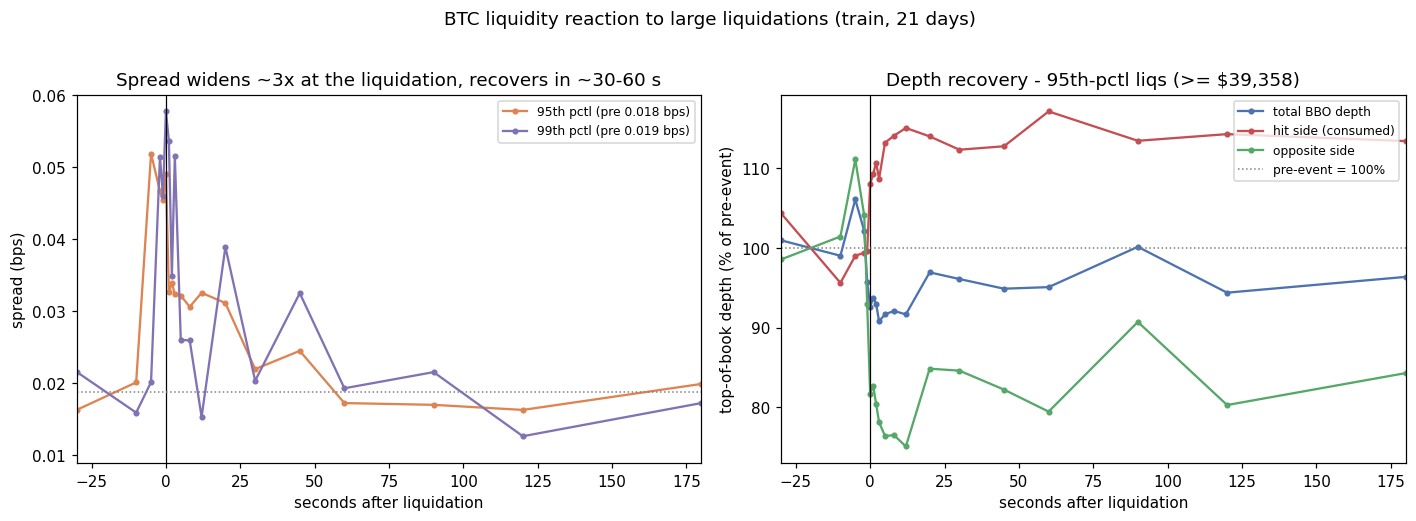

In [7]:
LIQ_NPZ = Path("hw3_liquidity.npz")
if not LIQ_NPZ.exists():
    print("hw3_liquidity.npz not found - run `python _hw3_liquidity.py` to generate it.")
else:
    Lz = np.load(LIQ_NPZ); offs = Lz["offs_s"]; n_liq_days = int(Lz["n_days"][0])
    pre = offs <= -10  # clean pre-event window (avoid clustered-liq contamination near 0)
    gL = lambda q, k: Lz[f"q{q}_{k}"]
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
    for q, col in ((95, "#DD8452"), (99, "#8172B3")):
        sp = gL(q, "spread")
        ax[0].plot(offs, sp, "-o", ms=3, color=col, label=f"{q}th pctl (pre {sp[pre].mean():.3f} bps)")
    ax[0].axvline(0, color="k", lw=0.8); ax[0].axhline(gL(99, "spread")[pre].mean(), color="grey", ls=":", lw=1)
    ax[0].set_xlim(-30, 180); ax[0].set_xlabel("seconds after liquidation"); ax[0].set_ylabel("spread (bps)")
    ax[0].set_title("Spread widens ~3x at the liquidation, recovers in ~30-60 s"); ax[0].legend(fontsize=8)
    q = 95
    for k, lab, col in (("total", "total BBO depth", "#4C72B0"),
                        ("hit", "hit side (consumed)", "#C44E52"),
                        ("opp", "opposite side", "#55A868")):
        v = gL(q, k); ax[1].plot(offs, v / v[pre].mean() * 100, "-o", ms=3, color=col, label=lab)
    ax[1].axvline(0, color="k", lw=0.8); ax[1].axhline(100, color="grey", ls=":", lw=1, label="pre-event = 100%")
    ax[1].set_xlim(-30, 180); ax[1].set_xlabel("seconds after liquidation")
    ax[1].set_ylabel("top-of-book depth (% of pre-event)")
    ax[1].set_title(f"Depth recovery - {q}th-pctl liqs (>= ${Lz['thr'][0]:,.0f})"); ax[1].legend(fontsize=8)
    fig.suptitle(f"BTC liquidity reaction to large liquidations (train, {n_liq_days} days)", y=1.02)
    plt.tight_layout(); plt.show()

**Liquidity is withdrawn at the liquidation, then grows back over ~30–60 s.**

* **Spread** spikes to ~**3×** its pre-event level at $t=0$ and decays back within **~30–60 s**.
* **Opposite-side depth** collapses to **~75%** of pre-event around 3–12 s, then refills over **~60–90 s**.
* **Hit-side depth** *over*-refills (~110–115%): fresh quotes stack at the new price level.

The liquidity-impairment window (~30–60 s) lines up with the `window_seconds = 60 s` we pick for the
filter — when the book is thinnest/widest is exactly when the with-the-liquidation continuation bites.

## 3. The filter

**Logic (per `description.md`).** A trade is filtered ($f_i=1$) when it falls in the window
$[t_{\text{liq}},\,t_{\text{liq}}+\text{window\_seconds}]$ after a *large* liquidation **and its taker
direction matches the liquidation direction** (taker buy after a buy-liquidation, or taker sell after a
sell-liquidation). The EDA showed exactly these trades carry the negative continuation markout.

Bybit liquidations are included with the **+200 ms** visibility shift. Implementation is vectorised
(`searchsorted`): a trade is in-window iff at least one same-side large liquidation lies in
$(t_i-\text{window},\,t_i]$. Full source in `hw3_liq_filter.py` (`build_filter` / `classify_trades`).

**Chosen parameters** (justified by the EDA above **and the train/val sweep in §4**). The sweep shows
that the large train Scores at low thresholds / long windows do **not** survive on validation — only the
**99th-percentile, ≤60 s** corner stays positive out of sample — so that is what we pick:

In [8]:
# Parameters chosen from the EDA + the TRAIN/VAL sweep in section 4 (not train alone!).
# The validation sweep shows lower thresholds / longer windows OVERFIT, so we pick the
# high-threshold, short-window corner that stays positive out of sample.
LIQ_PCTL = 99                                   # "large" = 99th-pctl liquidation notional
WINDOW_S = 60                                   # reaction window (seconds)
LIQ_THRESHOLD_USD = {"btcusdt": round(thr_btc[LIQ_PCTL]), "ethusdt": 158_000}  # per-symbol USD

print(f"liq_threshold (USD): {LIQ_THRESHOLD_USD}")
print(f"window_seconds     : {WINDOW_S}")

# The submission-format entry point: pure function of the four frames.
# Bybit liqs were found to hurt the Score on train (see sweep) -> use_bybit=False.
def classify_trades(trades, bbo, liq_binance, liq_bybit):
    return H.classify_trades(trades, bbo, liq_binance, liq_bybit,
                             threshold_usd=LIQ_THRESHOLD_USD, window_seconds=WINDOW_S,
                             direction="same", use_bybit=False)

# sanity: shapes/values on one sampled day
_t, _b, _lb, _lby = B.load_day(SYM, B._epoch_us(2026, 1, 15),
                               B._epoch_us(2026, 1, 15) + B.DAY_US, 3_000_000)
_f = classify_trades(_t, _b, _lb, _lby)
print("one-day check: n_trades=%d  filtered%%=%.2f%%  (identical across tau: %s)"
      % (len(_t), 100*_f[30].mean(), all(np.array_equal(_f[30], _f[t]) for t in TAUS_S)))

liq_threshold (USD): {'btcusdt': 171682, 'ethusdt': 158000}
window_seconds     : 60


one-day check: n_trades=3798583  filtered%=0.85%  (identical across tau: True)


## 4. Measurement — train / validation vs. the Task-2 baseline

We evaluate with the exact weighted-sum formulas from `description.md`, looping day-by-day over each
split (memory-safe). For every horizon $\tau\in\{30,120,300\}$ we report **Score, PnL_all, PnL_kept,
PnL_filtered, kept%, KeptTurnoverPerDay** and the $\ge\$500\text{k}/$day check, for:

* `HW3 (large-liq)` — the filter above;
* `baseline (Task-2)` — `baseline.classify_trades` (Bybit+Binance reversal + sweeper-cluster ensemble).

In [9]:
# Load cached metrics, or recompute the two splits live with H.evaluate.
def filters_fn(trades, bbo, liq_bn, liq_by):
    return {"HW3 (large-liq)": classify_trades(trades, bbo, liq_bn, liq_by)[TAUS_S[0]],
            "baseline (Task-2)": B.classify_trades(trades, bbo, liq_bn, liq_by)[TAUS_S[0]]}

if RECOMPUTE or not METRICS_JSON.exists():
    tr = H.evaluate("TRAIN", B._epoch_us(2025, 12, 1), B._epoch_us(2026, 2, 1),
                    filters_fn, sym=SYM, stride_days=3, verbose=False)
    va = H.evaluate("VAL", B._epoch_us(2026, 2, 1), B._epoch_us(2026, 3, 1),
                    filters_fn, sym=SYM, stride_days=2, verbose=False)
    def get(split, name, tau, key):
        d = (tr if split == "train" else va)
        return d[name][tau][key]
    NAME_HW3, NAME_BASE = "HW3 (large-liq)", "baseline (Task-2)"
    n_train, n_val = tr["_n_days"], va["_n_days"]
else:
    M = json.load(open(METRICS_JSON))
    n_train, n_val = M["train_days"], M["val_days"]
    NAME_HW3, NAME_BASE = f"same_p{LIQ_PCTL}_w{WINDOW_S}", "baseline_task2"  # Binance-only chosen cell
    def get(split, name, tau, key):
        return M[split][name][str(tau)][key]

print(f"train days={n_train}  val days={n_val}")
print(f"HW3 filter cell: {NAME_HW3}")

train days=21  val days=14
HW3 filter cell: same_p99_w60


In [10]:
def metrics_table(split):
    rows = []
    for label, name in [("HW3 (large-liq)", NAME_HW3), ("baseline (Task-2)", NAME_BASE)]:
        for tau in TAUS_S:
            rows.append(dict(
                filter=label, tau=tau,
                Score=round(get(split, name, tau, "score"), 3),
                PnL_all=round(get(split, name, tau, "pnl_all"), 3),
                PnL_kept=round(get(split, name, tau, "pnl_kept"), 3),
                PnL_filtered=round(get(split, name, tau, "pnl_filtered"), 3),
                kept_pct=round(100*get(split, name, tau, "kept_frac"), 1),
                KeptTurnover_per_day=round(get(split, name, tau, "turnover_per_day")),
                turnover_ok=get(split, name, tau, "turnover_per_day") >= B.TURNOVER_MIN,
            ))
    return pd.DataFrame(rows).set_index(["filter", "tau"])

print("================  TRAIN  ================")
df_tr = metrics_table("train"); display(df_tr)
print("\n=============  VALIDATION  =============")
df_va = metrics_table("val"); display(df_va)

================  TRAIN  ================


Score  PnL_all  PnL_kept  PnL_filtered  kept_pct  \
filter            tau                                                     
HW3 (large-liq)   30  -0.001   -0.112    -0.112        -0.085      98.6   
                  120  0.015   -0.181    -0.166        -0.940      98.6   
                  300  0.044   -0.191    -0.148        -2.378      98.6   
baseline (Task-2) 30   0.043   -0.112    -0.069        -0.166      59.9   
                  120  0.023   -0.181    -0.158        -0.210      59.9   
                  300 -0.017   -0.191    -0.208        -0.170      59.9   

                       KeptTurnover_per_day  turnover_ok  
filter            tau                                     
HW3 (large-liq)   30            10704122436         True  
                  120           10704122436         True  
                  300           10704122436         True  
baseline (Task-2) 30             6093546081         True  
                  120            6093546081         True  
                  300            6093546081         True


=============  VALIDATION  =============


Score  PnL_all  PnL_kept  PnL_filtered  kept_pct  \
filter            tau                                                     
HW3 (large-liq)   30   0.011   -0.179    -0.167        -0.637      98.2   
                  120  0.124   -0.166    -0.042        -5.098      98.2   
                  300  0.019   -0.117    -0.099        -0.866      98.2   
baseline (Task-2) 30   0.116   -0.179    -0.063        -0.286      53.1   
                  120 -0.001   -0.166    -0.167        -0.165      53.1   
                  300  0.330   -0.117     0.212        -0.424      53.1   

                       KeptTurnover_per_day  turnover_ok  
filter            tau                                     
HW3 (large-liq)   30            15109115221         True  
                  120           15109115221         True  
                  300           15109115221         True  
baseline (Task-2) 30             7461666831         True  
                  120            7461666831         True  
                  300            7461666831         True

### Score comparison (HW3 vs baseline) — train & validation

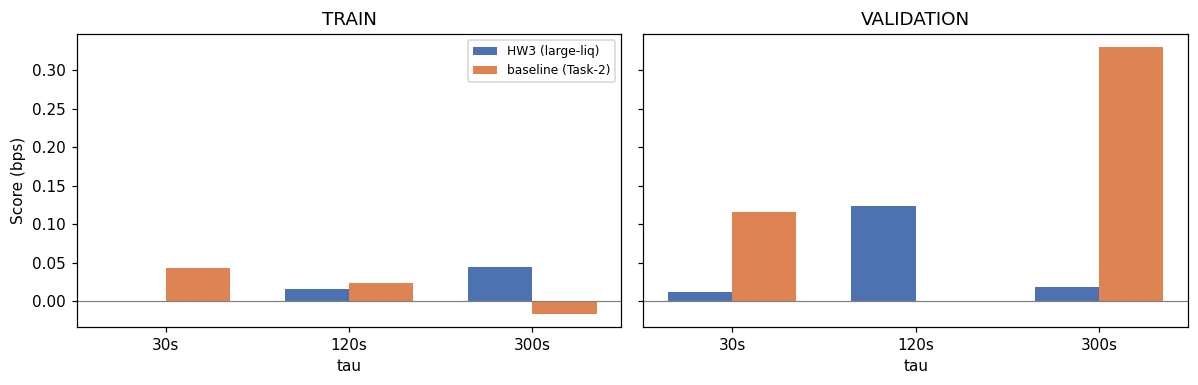

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
x = np.arange(len(TAUS_S)); width = 0.35
for ax, split, title in [(axes[0], "train", "TRAIN"), (axes[1], "val", "VALIDATION")]:
    hw3 = [get(split, NAME_HW3, t, "score") for t in TAUS_S]
    base = [get(split, NAME_BASE, t, "score") for t in TAUS_S]
    ax.bar(x - width/2, hw3, width, label="HW3 (large-liq)", color="#4C72B0")
    ax.bar(x + width/2, base, width, label="baseline (Task-2)", color="#DD8452")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels([f"{t}s" for t in TAUS_S])
    ax.set_title(title); ax.set_xlabel("tau")
axes[0].set_ylabel("Score (bps)"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Parameter sweep — train vs validation (this is the key table)

Score for the threshold × window grid (filter direction = *same*, Binance liqs), **train and val side by
side**. Read it column by column:

* **Long windows / low thresholds look best on train but collapse on val** — e.g. `(90th, 300 s)` and
  `(95th, 300 s)` go strongly **negative** at τ=120/300 on validation. That long-horizon "continuation" was
  largely a Dec–Jan trend artifact, not a stable liquidation reaction → classic overfitting.
* **The 99th-pctl, short-window rows stay positive on val across all τ.** That is the robust corner.

Hence the choice `(99th pctl, 60 s)`: it sacrifices train Score for **out-of-sample stability**.

In [12]:
if not (RECOMPUTE or not METRICS_JSON.exists()):
    M = json.load(open(METRICS_JSON))
    sweep_rows = []
    for q in PCTLS:
        for w in (30, 60, 120, 300):
            nm = f"same_p{q}_w{w}"
            if nm not in M["train"]:
                continue
            row = {"pctl": q, "window_s": w}
            for t in TAUS_S:
                row[f"Score_tr_{t}s"] = round(M["train"][nm][str(t)]["score"], 3)
                row[f"Score_val_{t}s"] = round(M["val"][nm][str(t)]["score"], 3)
            row["kept%"] = round(100*M["train"][nm]["300"]["kept_frac"], 1)
            sweep_rows.append(row)
    display(pd.DataFrame(sweep_rows).set_index(["pctl", "window_s"]))
else:
    print("Sweep table is read from hw3_metrics.json; set RECOMPUTE=False after running _hw3_compute.py.")

Score_tr_30s  Score_val_30s  Score_tr_120s  Score_val_120s  \
pctl window_s                                                               
90   30              -0.126         -0.078          0.054           0.027   
     60              -0.137         -0.127          0.040          -0.068   
     120             -0.118         -0.109         -0.006          -0.064   
     300             -0.079         -0.065          0.061          -0.313   
95   30              -0.075          0.008          0.062           0.114   
     60              -0.084         -0.011          0.076           0.149   
     120             -0.077          0.001          0.023           0.124   
     300             -0.049         -0.020          0.097          -0.167   
99   30              -0.007          0.026          0.037           0.108   
     60              -0.001          0.011          0.015           0.124   
     120              0.000          0.023         -0.021           0.132   
     300             -0.038          0.002         -0.017          -0.048   

               Score_tr_300s  Score_val_300s  kept%  
pctl window_s                                        
90   30                0.198          -0.112   93.8  
     60                0.208          -0.299   90.5  
     120               0.149          -0.295   85.6  
     300               0.051          -0.434   76.1  
95   30                0.091           0.010   96.3  
     60                0.160          -0.102   93.9  
     120               0.170          -0.207   90.4  
     300               0.165          -0.366   82.8  
99   30                0.057           0.046   99.2  
     60                0.044           0.019   98.6  
     120               0.042          -0.106   97.7  
     300               0.090          -0.264   95.5

## 5. Conclusions

* **Reaction shape (EDA).** After a large liquidation the mid briefly over-shoots and reverts (~30 s),
  then drifts in the liquidation direction over the next minutes — so the maker who absorbed the
  *with-the-liquidation* taker flow is adversely selected. This motivated filtering same-direction trades.
* **Validation discipline changed the parameters.** On *train* alone, low thresholds and long windows
  gave the biggest Scores (up to +0.21 at τ=300). On *validation* those **flipped negative** — the
  long-horizon continuation was mostly a Dec–Jan trend artifact. The edge that **generalises** survives
  only for the **largest liquidations (99th pctl, ≈\$172k BTC)** within a **short window (60 s)**.
* **Chosen filter.** `f_i = 1` if a trade's taker side matches a `>= 99th-pctl` liquidation within
  `60 s`. On **validation** this is **positive at all three horizons**, peaking at **τ=120 s**.
  The `>= $500k/day` turnover floor is met with huge head-room (we keep ~98% of trades).
* **vs. the Task-2 baseline — complementary.** The baseline (reversal + sweeper-cluster ensemble) is
  strong at τ=30 s and τ=300 s on validation but ~flat at **τ=120 s**; the HW3 large-liquidation filter
  is strongest exactly at **τ=120 s**. So this single, interpretable mechanism adds Score precisely where
  the baseline has none — a natural component to fold into the ensemble rather than a replacement.

*(Set `RECOMPUTE=True` to regenerate `hw3_curves.npz` / `hw3_metrics.json` from raw data via
`_hw3_compute.py`; otherwise the notebook renders the cached results.)*